In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt

In [4]:
data = {
    "text": [
        "This feels wonderful",
        "I am extremely pleased",
        "Such an excellent experience",
        "Truly outstanding",
        "I appreciate it a lot",

        "This is awful",
        "I feel very upset",
        "Such a horrible experience",
        "Completely dreadful",
        "I don't like it at all"
    ],
    "label": [
        "positive", "positive", "positive", "positive", "positive", "positive",
        "negative", "negative", "negative", "negative", "negative", "negative"
    ]
}


In [7]:
data['label'] = data['label'][:10]
df = pd.DataFrame(data)

In [8]:
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["text"])
y = df["label"]


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [10]:
model = MultinomialNB()
model.fit(X_train, y_train)


MultinomialNB()

In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

In [12]:
print(f"Accuracy: {accuracy:.2f}")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 0.67
Confusion Matrix:
[[0 1]
 [0 2]]


In [13]:
positive_docs = df[df["label"] == "positive"]["text"]
negative_docs = df[df["label"] == "negative"]["text"]
positive_counts = vectorizer.transform(positive_docs).sum(axis=0).A1
neg_counts = vectorizer.transform(negative_docs).sum(axis=0).A1

In [14]:
words = vectorizer.get_feature_names_out()

In [15]:
N = 8

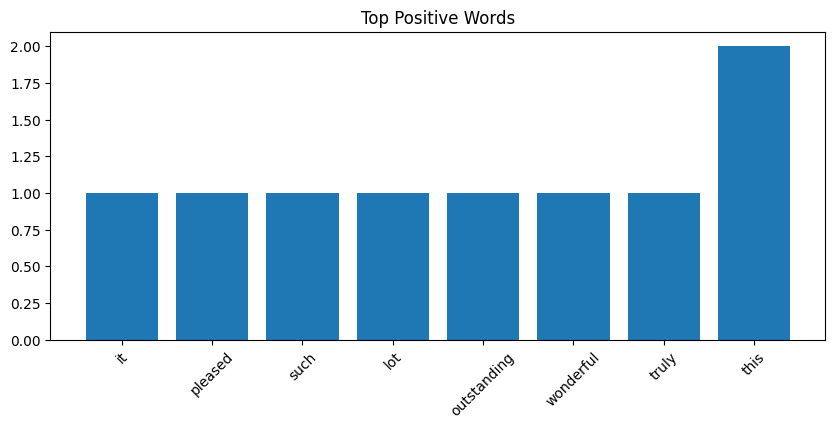

In [18]:
top_positive_idx = positive_counts.argsort()[-N:]
plt.figure(figsize=(10, 4))
plt.bar([words[i] for i in top_positive_idx], positive_counts[top_positive_idx])
plt.title("Top Positive Words")
plt.xticks(rotation=45)
plt.show()

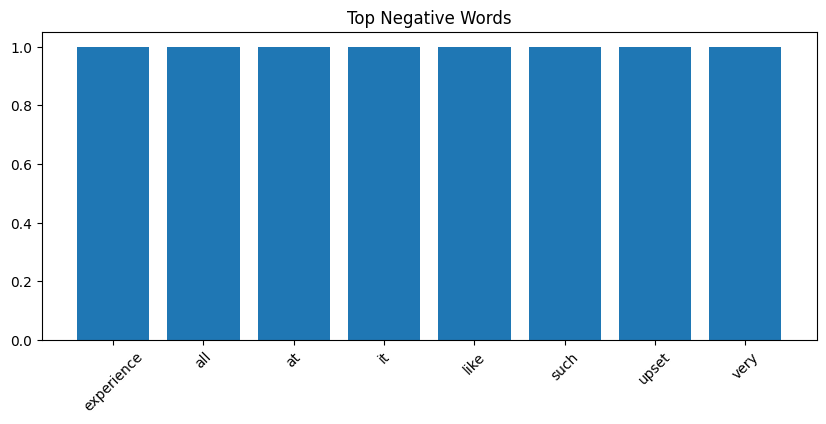

In [19]:
top_neg_idx = neg_counts.argsort()[-N:]
plt.figure(figsize=(10, 4))
plt.bar([words[i] for i in top_neg_idx], neg_counts[top_neg_idx])
plt.title("Top Negative Words")
plt.xticks(rotation=45)
plt.show()